# Supplementary Figure S3: Per-Organ Detailed Spatial Risk Maps
Spatial AD risk maps for each organ from CTRL1 samples.

In [1]:
%matplotlib inline
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import os

LEGEND_FS = 11; TICK_FS = 12; LABEL_FS = 13; TITLE_FS = 13; TEXT_FS = 12

def save_all_formats(fig, basepath, dpi=300):
    fig.savefig(f"{basepath}.pdf", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.png", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.svg", bbox_inches="tight")

BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures', exist_ok=True)

## Load spot-level AD p-values and spatial coordinates

In [3]:
# Load spot-level results from all available processed samples
available_samples = sorted([d for d in os.listdir(f'{BASE}/models/gsmap_output/')
                            if os.path.isdir(f'{BASE}/models/gsmap_output/{d}')])
ctrl1_samples = [s for s in available_samples if 'CTRL1' in s]
print('CTRL1 samples:', ctrl1_samples)

# Load spatial coords from per-organ h5ad and merge with p-values
all_spots = []
for sname in ctrl1_samples:
    # Load p-values
    pval_path = f'{BASE}/models/gsmap_output/{sname}/spatial_ldsc/{sname}_AD.csv.gz'
    if not os.path.exists(pval_path):
        continue
    pvals = pd.read_csv(pval_path)
    
    # Load spatial coords
    organ_file = f'{BASE}/data/st/per_organ/{sname}.h5ad'
    adata_org = ad.read_h5ad(organ_file, backed='r')
    coords = adata_org.obs[['x_plotting', 'y_plotting', 'Organ_Full_Name', 'annotation']].copy()
    coords.index.name = 'spot'
    coords = coords.reset_index()
    coords.rename(columns={'index': 'spot'}, inplace=True)
    
    # Merge
    merged = pvals.merge(coords, on='spot', how='inner')
    merged['sample_name'] = sname
    merged['logp'] = -np.log10(merged['p'].clip(lower=1e-300))
    all_spots.append(merged)
    del adata_org

spots_df = pd.concat(all_spots, ignore_index=True)
print(f'Total spots: {len(spots_df)}')
print(f'Organs: {spots_df["Organ_Full_Name"].unique()}')

CTRL1 samples: ['Bone_Marrow_CTRL1', 'Brain_CTRL1', 'Brown_Fat_CTRL1', 'Colon_CTRL1', 'Heart_CTRL1', 'Kidney_CTRL1', 'Liver_CTRL1', 'Lung_CTRL1', 'Lymph_Node_CTRL1', 'Muscle_CTRL1', 'Pancreas_CTRL1', 'Skin_CTRL1', 'Small_Intestine_CTRL1', 'Spleen_CTRL1', 'Stomach_CTRL1', 'Thymus_CTRL1']


Total spots: 552229
Organs: ['Bone Marrow' 'Brain' 'Brown Fat' 'Colon' 'Heart' 'Kidney' 'Liver' 'Lung'
 'Lymph Node' 'Muscle' 'Pancreas' 'Skin' 'Small Intestine' 'Spleen'
 'Stomach' 'Thymus']


## Grid of spatial risk maps (one per organ)

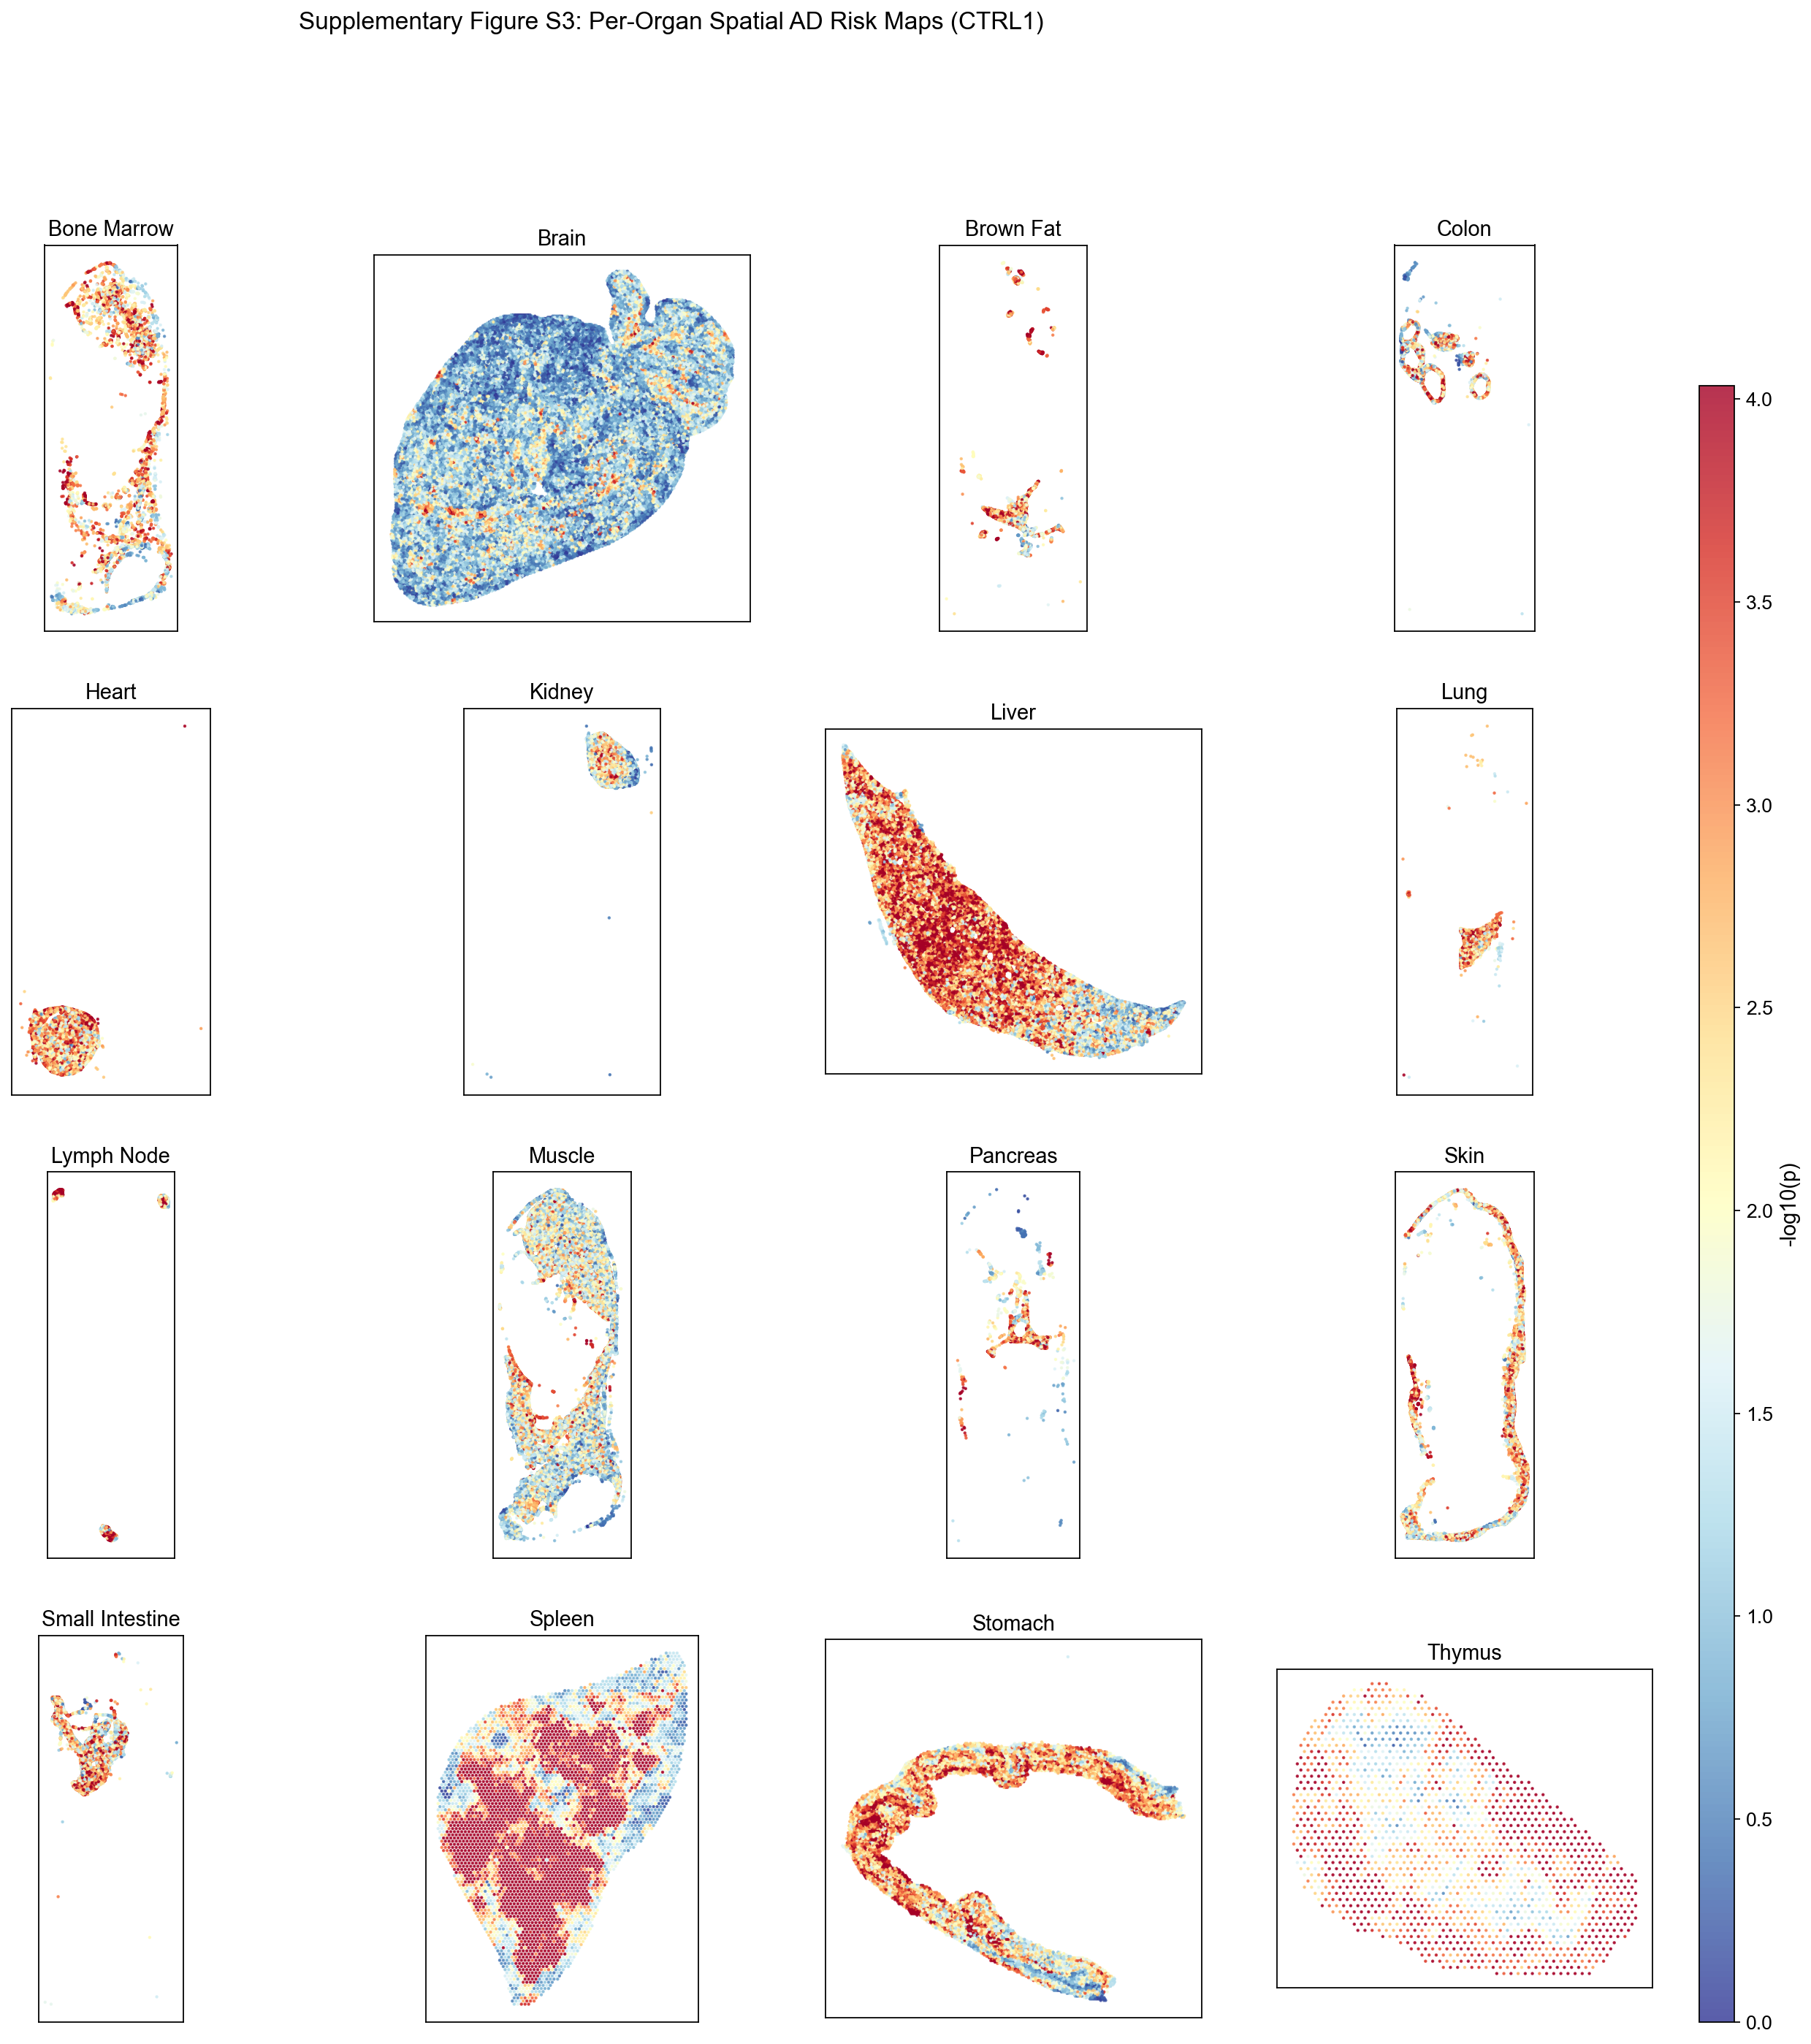

In [4]:
organs = sorted(spots_df['Organ_Full_Name'].unique())
n_organs = len(organs)
ncols = 4
nrows = max(1, int(np.ceil(n_organs / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

vmax_global = spots_df['logp'].quantile(0.95)

for i, organ in enumerate(organs):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    sub = spots_df[spots_df['Organ_Full_Name'] == organ]
    sc = ax.scatter(
        sub['x_plotting'], sub['y_plotting'],
        c=sub['logp'], cmap='RdYlBu_r', s=1, alpha=0.8,
        vmin=0, vmax=vmax_global, rasterized=True
    )
    ax.set_title(organ, fontsize=TITLE_FS, fontweight='bold')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])

# Turn off unused axes
for i in range(n_organs, nrows * ncols):
    row, col = divmod(i, ncols)
    axes[row, col].axis('off')

# Add colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('-log10(p)', fontsize=LABEL_FS)
cbar.ax.tick_params(labelsize=TICK_FS)

fig.suptitle('Supplementary Figure S3: Per-Organ Spatial AD Risk Maps (CTRL1)', fontsize=TITLE_FS + 2, y=1.01)
save_all_formats(fig, f'{BASE}/figures/S03_per_organ_risk_maps')